Title: Phase 1: Classical SVM benchmark on breast cancer dataset
Short description of what the notebook demonstrates (classical ML baseline before quantum comparisons).

Imports cell
Markdown above: explain why these libraries are needed (scikit‑learn for SVM, NumPy for arrays, etc.).

In [1]:
import sys
import os
import time
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Path setup cell
Markdown: explain that this ensures imports from src/utils

In [2]:
#ROOT_DIR = os.getcwd()
#SRC_PATH = os.path.join(ROOT_DIR, "src")
#sys.path.append(SRC_PATH)

import os, sys

# Notebook is in /app/src/phase1 → go up one level
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

print([p for p in sys.path if "src" in p])  # sanity check


['/app/src']


Modular imports cell
Markdown: note that these are your custom utilities for logging, visualization, and dataset loading.

In [3]:
from utils.logger import log_results
from utils.visualizer import plot_projected_decision_boundary
from utils.data_loader import load_dataset_from_config

Dataset load cell
Markdown: explain dataset source, features vs target, and why you drop the target column.

In [4]:
df, cfg = load_dataset_from_config()
X = df.drop(columns=["target"]).values
y = df["target"].values


Train/test split + scaling cell
Markdown: explain importance of scaling for SVMs.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model training cell
Markdown: explain why you chose a linear kernel as baseline.

In [6]:
model = SVC(kernel="linear")

start = time.time()
model.fit(X_train, y_train)
training_time = round(time.time() - start, 4)


Evaluation cell
Markdown: explain what generalization gap means and why it matters.

In [7]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
generalization_gap = round(train_accuracy - test_accuracy, 4)

metrics = {
    "model": "SVM_BreastCancer",
    "dataset": cfg["dataset"],
    "accuracy": test_accuracy,
    "train_accuracy": train_accuracy,
    "generalization_gap": generalization_gap,
    "training_time": training_time
}
log_results(metrics)

print("\n=== Classical SVM Breast Cancer Results ===")
for k, v in metrics.items():
    print(f"{k}: {v}")



[log_results] wrote row to: /app/results/results.csv

=== Classical SVM Breast Cancer Results ===
model: SVM_BreastCancer
dataset: breast_cancer
accuracy: 0.9473684210526315
train_accuracy: 0.9773869346733668
generalization_gap: 0.03
training_time: 0.0249


Visualization cell
Markdown: explain PCA projection and why visualization helps interpret the classifier.

[visualizer] saved plot to: /app/plots/classical_svm_breast_cancer_pca_projection.png


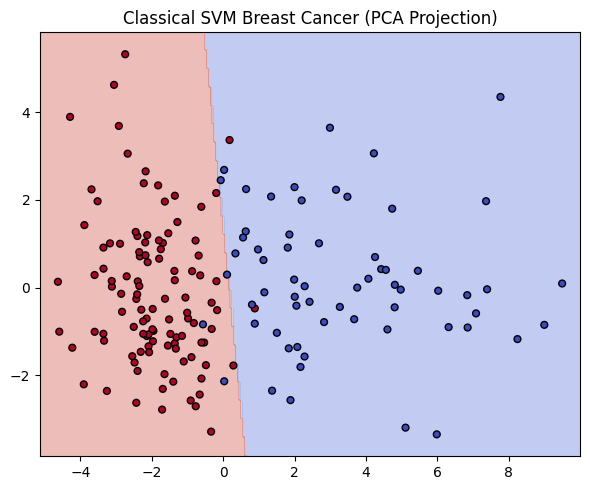

'/app/plots/classical_svm_breast_cancer_pca_projection.png'

In [8]:
plot_projected_decision_boundary(model, X_test, y_test, title="Classical SVM Breast Cancer (PCA Projection)")